In [1]:
import pandas as pd
import glob

output_dir="../../output/coverage_dependence_homogeneous_l5"
prefix = "Ecoli_K12_MG1655"

id = [100, 98, 96, 94, 92, 90]
cov = [100]

results = {}

for i in id:
    for c in cov:
        a_list = []
        b_list = []
        coverage_list = []
        
        output_file_name = f"{output_dir}/{prefix}_depth_{c}_id_{i}_exp_[0-9+]_bidirectional.csv"
        all_files = glob.glob(output_file_name)
        for file in all_files:
            df = pd.read_csv(file)

            estimated_a = df['a']
            estimated_b = df['b']
            estimated_coverage = df['true_median_coverage']

            a_list.extend(estimated_a.tolist())
            b_list.extend(estimated_b.tolist())
            coverage_list.extend(estimated_coverage.tolist())
        
        results[f"{prefix}_depth_{c}_id_{i}"] = {
            'a': a_list,
            'b': b_list,
            'true_median_coverage': coverage_list
        }


/tmp/ipykernel_7072/3371208329.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


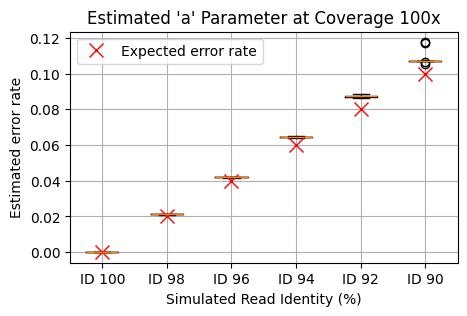

In [4]:
ground_truth_a = [0, 0.02, 0.04, 0.06, 0.08, 0.1]

import matplotlib.pyplot as plt
import numpy as np

coverage = 100

# Plot box plot for 'a' parameter
plt.figure(figsize=(5,3))
data_to_plot = []
labels = []
for i in id:
    key = f"{prefix}_depth_{coverage}_id_{i}"
    data_to_plot.append(results[key]['a'])
    labels.append(f"ID {i}")
plt.boxplot(data_to_plot, labels=labels)

# Plot ground truth as red crosses
for i, gt_a in enumerate(ground_truth_a):
    plt.plot(i + 1, gt_a, 'rx', markersize=10, label='Expected error rate' if i == 0 else "")

plt.title(f"Estimated 'a' Parameter at Coverage {coverage}x")
plt.xlabel("Simulated Read Identity (%)")
plt.ylabel("Estimated error rate")
plt.legend()
plt.grid()
plt.show()



/tmp/ipykernel_19854/3552064345.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


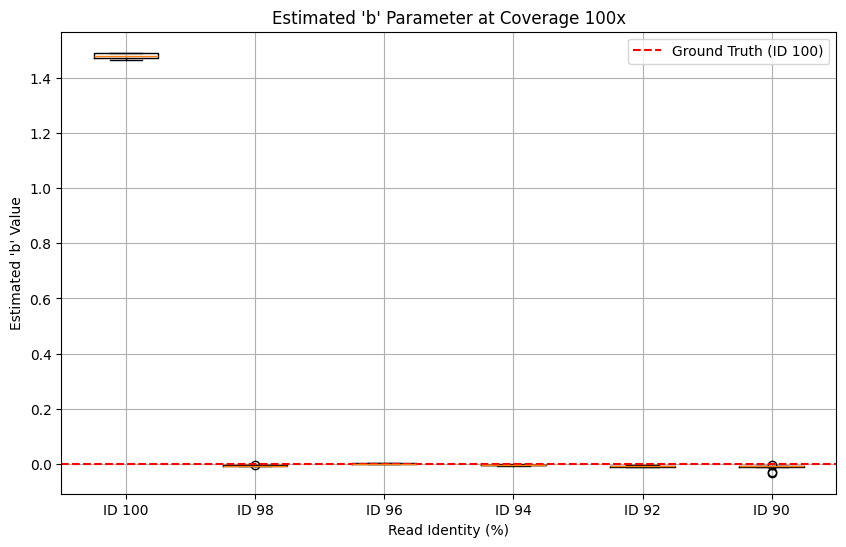

In [11]:
ground_truth_b = [0, 0, 0, 0, 0, 0]

import matplotlib.pyplot as plt
import numpy as np

coverage = 100

# Plot box plot for 'a' parameter
plt.figure(figsize=(10, 6))
data_to_plot = []
labels = []
for i in id:
    key = f"{prefix}_depth_{coverage}_id_{i}"
    data_to_plot.append(results[key]['b'])
    labels.append(f"ID {i}")
plt.boxplot(data_to_plot, labels=labels)
plt.axhline(y=ground_truth_a[id.index(100)], color='r', linestyle='--', label='Ground Truth (ID 100)')
plt.title(f"Estimated 'b' Parameter at Coverage {coverage}x")
plt.xlabel("Read Identity (%)")
plt.ylabel("Estimated 'b' Value")
plt.legend()
plt.grid()
plt.show()


/tmp/ipykernel_19854/840731883.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


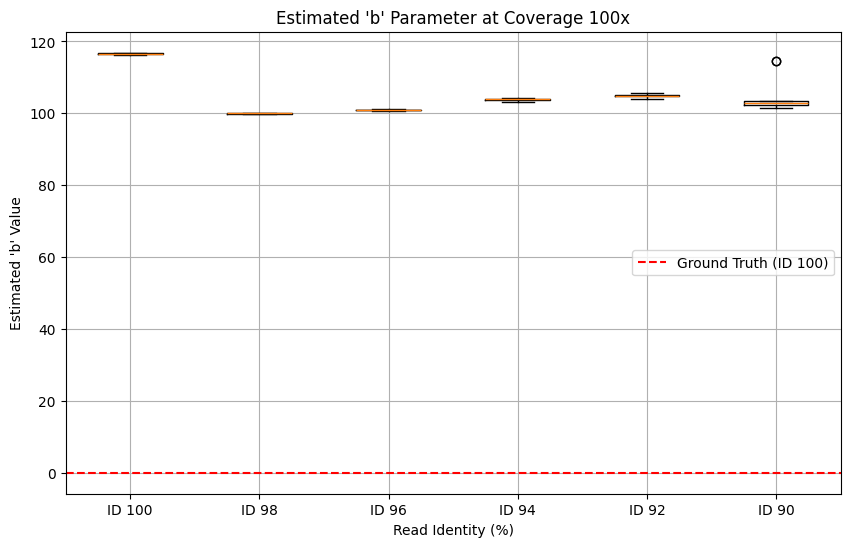

In [12]:
ground_truth_b = [100, 100, 100, 100, 100, 100]

import matplotlib.pyplot as plt
import numpy as np

coverage = 100

# Plot box plot for 'a' parameter
plt.figure(figsize=(10, 6))
data_to_plot = []
labels = []
for i in id:
    key = f"{prefix}_depth_{coverage}_id_{i}"
    data_to_plot.append(results[key]['true_median_coverage'])
    labels.append(f"ID {i}")
plt.boxplot(data_to_plot, labels=labels)
plt.axhline(y=ground_truth_a[id.index(100)], color='r', linestyle='--', label='Ground Truth (ID 100)')
plt.title(f"Estimated 'b' Parameter at Coverage {coverage}x")
plt.xlabel("Read Identity (%)")
plt.ylabel("Estimated 'b' Value")
plt.legend()
plt.grid()
plt.show()
